## Nama : Syerli Khuntum Khaira
## NIM : 4222301028
### Kelas : RE 6 A Pagi
### Assignment13 - Transfer Learning
### Image Classification using Transfer Learning: Deteksi Jenis Sampah di Sekitar Kampus

1. Import Library

In [14]:
# melakukan install libarry
%pip install tensorflow matplotlib numpy scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import tensorflow as tf

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.16.1


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [17]:
# lokasi dataset yang digunakan
dataset_path = 'C:/Users/Asus/Documents/12/archive/TrashType_Image_Dataset'

In [18]:
# melihat folder
import os

classes = sorted(os.listdir(dataset_path))

print("Jumlah kelas :", len(classes))
print("Nama kelas :", classes)

#menampilkan jumlah setiap kelas
for folder in classes:
    total = len(os.listdir(os.path.join(dataset_path, folder)))
    print(f"{folder} : {total} gambar")

Jumlah kelas : 6
Nama kelas : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
cardboard : 403 gambar
glass : 501 gambar
metal : 410 gambar
paper : 594 gambar
plastic : 482 gambar
trash : 137 gambar


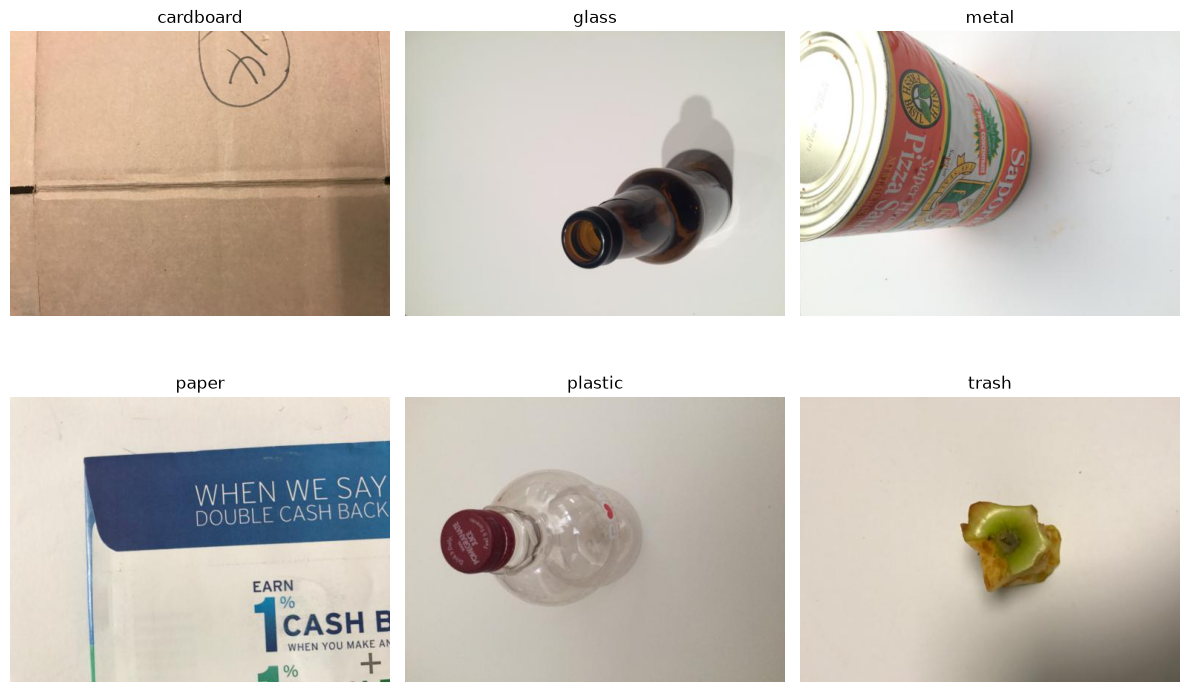

In [19]:
#visualisasi gambar
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i, folder in enumerate(classes):

    img_name = os.listdir(os.path.join(dataset_path, folder))[0]

    img_path = os.path.join(dataset_path, folder, img_name)

    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis("off")

plt.tight_layout()
plt.show()

2. Data Augmentation

In [20]:
#bertujuan untuk mengurangi overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

#melakukan training generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

#validasi generator
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [21]:
print(train_generator)

In [22]:
from PIL import Image
print("Pillow berhasil diimport!")


Pillow berhasil diimport!


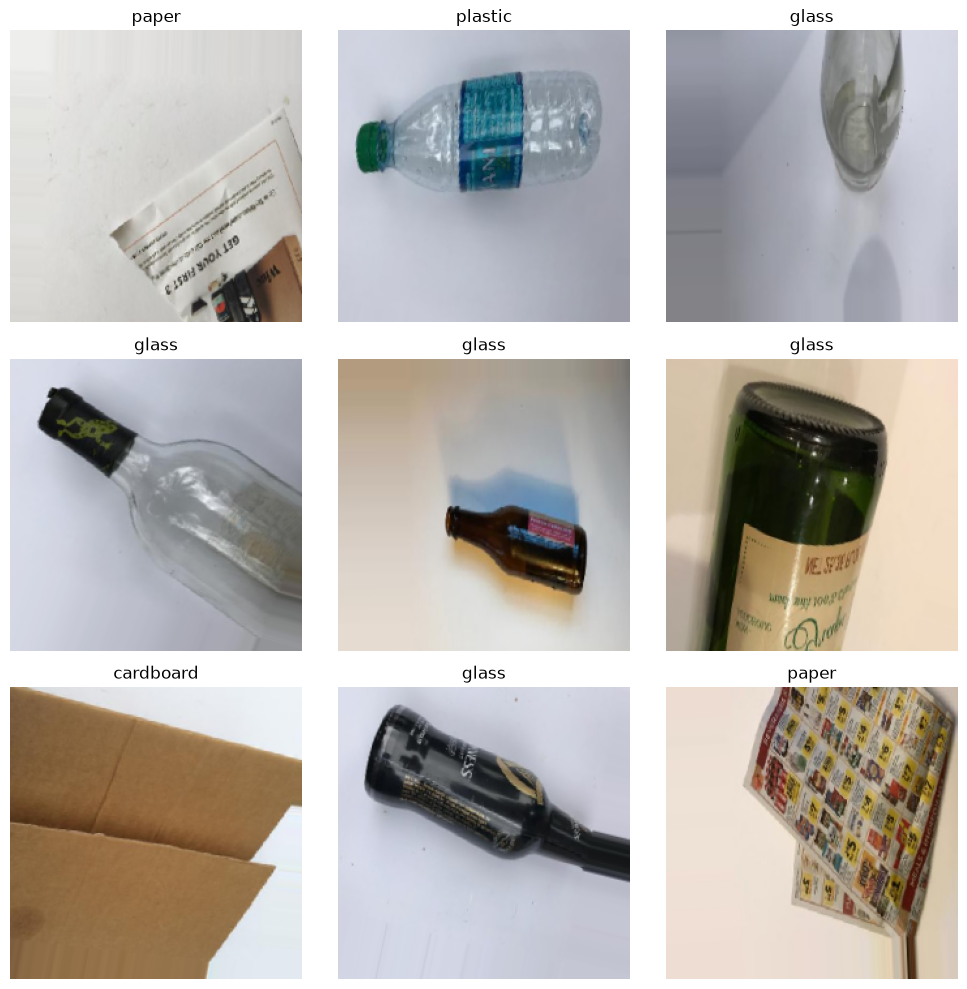

In [23]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

3. Membuat model transfer learning

In [29]:
import tensorflow as tf

from tensorflow.keras import models
from tensorflow.keras import layers

In [35]:
# Jumlah kelas
num_classes = train_generator.num_classes

# Load VGG16 Pre-trained
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze semua layer VGG16
base_model.trainable = False

# Membuat model Transfer Learning
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Ringkasan model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

4. Training model data

In [37]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [39]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 535s 8s/step - accuracy: 0.5361 - loss: 1.1584 - val_accuracy: 0.6282 - val_loss: 1.0826 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 524s 8s/step - accuracy: 0.5781 - loss: 1.0924 - val_accuracy: 0.6282 - val_loss: 1.0299 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 526s 8s/step - accuracy: 0.5983 - loss: 1.0380 - val_accuracy: 0.6541 - val_loss: 0.9944 - learning_rate: 0.0010
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 519s 8s/step - accuracy: 0.6156 - loss: 0.9953 - val_accuracy: 0.6302 - val_loss: 0.9772 - learning_rate: 0.0010
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 521s 8s/step - accuracy: 0.6280 - loss: 0.9718 - val_accuracy: 0.6819 - val_loss: 0.9206 - learning_rate: 0.0010
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 520s 8s/step - accuracy: 0.6413 - loss: 0.9421 - val_accuracy: 0.6819 - val_loss: 0.9105 - learning_rate: 0.0010
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 523s 8s/step - accuracy: 0.6527 - loss: 0.9118 - val_acc

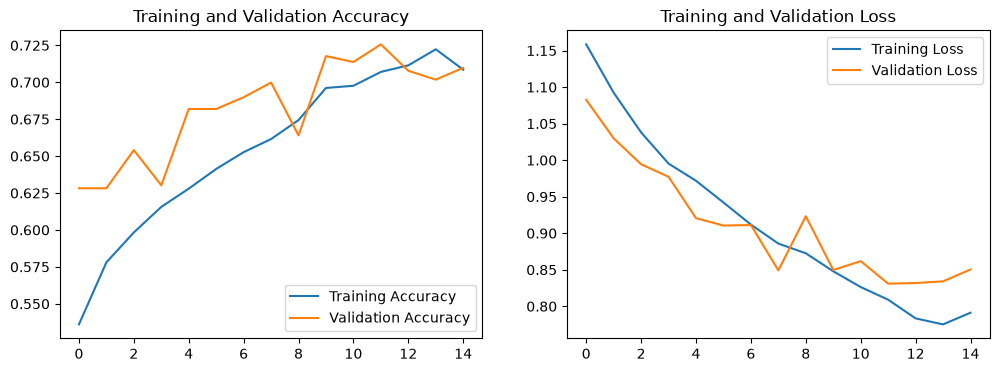

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [43]:
# Mengambil accuracy epoch terakhir
train_acc = acc[-1]
val_acc = val_acc[-1]

print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")

gap = train_acc - val_acc

print(f"Accuracy Gap : {gap:.4f}")

Training Accuracy   : 0.7085
Validation Accuracy : 0.7097
Accuracy Gap : -0.0012


1. Analisis Performa Model

Berdasarkan hasil pelatihan model klasifikasi jenis sampah menggunakan metode Transfer Learning VGG16, model menunjukkan performa yang Good Fit (Stabil) dan tidak mengalami overfitting.

Analisis Akurasi: Model memperoleh Training Accuracy sebesar 70.85% dan Validation Accuracy sebesar 70.97%. Selisih akurasi (Accuracy Gap) sebesar -0.0012 menunjukkan bahwa performa model pada data pelatihan dan data validasi hampir sama. Bahkan, validation accuracy sedikit lebih tinggi dibandingkan training accuracy. Hal ini menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data baru dan tidak hanya menghafal data pelatihan.

Analisis Loss: Berdasarkan grafik Training Loss dan Validation Loss, kedua kurva menunjukkan pola yang relatif stabil tanpa adanya peningkatan validation loss secara signifikan ketika training loss terus menurun. Hal ini mengindikasikan bahwa model belajar secara konsisten dan tidak mengalami gejala overfitting selama proses pelatihan.

2. Evaluasi Overfitting

Berdasarkan hasil evaluasi, model tidak mengalami overfitting karena nilai training accuracy dan validation accuracy hampir sama. Hal ini didukung oleh penerapan beberapa teknik, yaitu Transfer Learning VGG16, Freezing Layers, Data Augmentation, Dropout (0.5), EarlyStopping, dan ReduceLROnPlateau, sehingga model mampu melakukan klasifikasi dengan performa yang stabil.